## Decision tree

### Decision Tree 建模步骤：

1. 数据准备 / Data Preparation —— 分离特征（X）和目标变量（y）
2. 类别变量编码 / Categorical Encoding —— 对 Color、Source、Month 进行编码（如 One-Hot Encoding）
3. 训练集与测试集划分 / Train-Test Split
4. 模型构建 / Model Building —— 初始化 DecisionTreeClassifier
5. 模型训练 / Model Training —— 在训练集上 fit 模型
6. 模型预测 / Model Prediction —— 在测试集上 predict
7. 模型评估 / Model Evaluation —— 计算 Accuracy、Precision、Recall、F1、ROC-AUC
8. 交叉验证 / Cross Validation —— 5-Fold CV 验证模型稳定性
9. 超参数调优 / Hyperparameter Tuning —— 调整 max_depth、min_samples_split 等参数（可选但推荐）
10. 特征重要性分析 / Feature Importance Analysis —— 提取并可视化重要特征
11. 决策树可视化 / Tree Visualization —— 绘制决策树结构图（可选）

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/water_quality_cleaned_2.csv")
# 运行时，改成df = pd.read_csv("../data/processed/water_quality_cleaned.csv")

print("Number of observations:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

df.info()

Number of observations: 734756
Number of columns: 23

Column names:
['pH', 'Iron', 'Nitrate', 'Chloride', 'Lead', 'Zinc', 'Color', 'Turbidity', 'Fluoride', 'Copper', 'Odor', 'Sulfate', 'Conductivity', 'Chlorine', 'Manganese', 'Total Dissolved Solids', 'Source', 'Water Temperature', 'Air Temperature', 'Month', 'Day', 'Time of Day', 'Target']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734756 entries, 0 to 734755
Data columns (total 23 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   pH                      734756 non-null  float64
 1   Iron                    734756 non-null  float64
 2   Nitrate                 734756 non-null  float64
 3   Chloride                734756 non-null  float64
 4   Lead                    734756 non-null  float64
 5   Zinc                    734756 non-null  float64
 6   Color                   734756 non-null  object 
 7   Turbidity               734756 non-null  float64
 8   F

In [2]:
print("Color unique values:", df['Color'].nunique())
print(df['Color'].unique())

print("\nSource unique values:", df['Source'].nunique())
print(df['Source'].unique())

Color unique values: 5
['Faint Yellow' 'Light Yellow' 'Colorless' 'Near Colorless' 'Yellow']

Source unique values: 8
['Lake' 'River' 'Spring' 'Ground' 'Stream' 'Reservoir' 'Aquifer' 'Well']


#### 1. Data preparation

In [8]:
X_dt = df.drop(columns=['Target'])
y_dt = df['Target']

print("X_dt shape:", X_dt.shape)
print("y_dt shape:", y_dt.shape)

X_dt shape: (734756, 22)
y_dt shape: (734756,)


#### 2. Categorical Encoding：Color, Source
* Source is unordered categorical variable, so we choose one-hot encoding.

* Color: Colorless<Near Colorless<Faint Yellow<Light Yellow<Yellow, so we decide to use ordinal encoding

In [9]:
# Color: ordinal encoding (domain-based order)
color_order = ['Colorless', 'Near Colorless', 'Faint Yellow', 'Light Yellow', 'Yellow']
color_mapping = {cat: i for i, cat in enumerate(color_order)}
X_dt['Color'] = X_dt['Color'].map(color_mapping)

# Source: one-hot encoding (nominal variable)
X_dt = pd.get_dummies(X_dt, columns=['Source'], drop_first=False)

print("X_dt shape after encoding:", X_dt.shape)
print(X_dt.columns.tolist())

X_dt shape after encoding: (734756, 29)
['pH', 'Iron', 'Nitrate', 'Chloride', 'Lead', 'Zinc', 'Color', 'Turbidity', 'Fluoride', 'Copper', 'Odor', 'Sulfate', 'Conductivity', 'Chlorine', 'Manganese', 'Total Dissolved Solids', 'Water Temperature', 'Air Temperature', 'Month', 'Day', 'Time of Day', 'Source_Aquifer', 'Source_Ground', 'Source_Lake', 'Source_Reservoir', 'Source_River', 'Source_Spring', 'Source_Stream', 'Source_Well']


#### 3. Train-Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_dt, y_dt,
    test_size=0.2,
    random_state=42,
    stratify=y_dt
)

print("X_train_dt shape:", X_train_dt.shape)
print("X_test_dt shape:", X_test_dt.shape)
print("y_train_dt shape:", y_train_dt.shape)
print("y_test_dt shape:", y_test_dt.shape)

X_train_dt shape: (587804, 29)
X_test_dt shape: (146952, 29)
y_train_dt shape: (587804,)
y_test_dt shape: (146952,)


#### 4.Model Building: DecisionTreeClassifier

In [11]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

print(dt_model)

DecisionTreeClassifier(random_state=42)


#### 5. Model Training

In [12]:
dt_model.fit(X_train_dt, y_train_dt)

print("Model training complete")

模型训练完成 / Model training complete


#### 6. Model Prediction

In [13]:
y_pred_dt = dt_model.predict(X_test_dt)

print("Prediction complete")
print("First 10 prediction results:", y_pred_dt[:10])

Prediction complete
First 10 prediction results: [1 1 1 0 0 0 0 0 0 0]


#### 7. Model Evaluation: Accuracy、Precision、Recall、F1、ROC-AUC

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred_proba_dt = dt_model.predict_proba(X_test_dt)[:, 1]

accuracy_dt = accuracy_score(y_test_dt, y_pred_dt)
precision_dt = precision_score(y_test_dt, y_pred_dt)
recall_dt = recall_score(y_test_dt, y_pred_dt)
f1_dt = f1_score(y_test_dt, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test_dt, y_pred_proba_dt)

print("Accuracy:", accuracy_dt)
print("Precision:", precision_dt)
print("Recall:", recall_dt)
print("F1 Score:", f1_dt)
print("ROC-AUC:", roc_auc_dt)

Accuracy: 0.8355313299580815
Precision: 0.6440420072796706
Recall: 0.6381966001478196
F1 Score: 0.6411059798345782
ROC-AUC: 0.7663655307085063


#### 8. Cross Validation: 5-Fold CV

In [15]:
from sklearn.model_selection import cross_val_score

cv_scores_dt = cross_val_score(dt_model, X_train_dt, y_train_dt, cv=5, scoring='accuracy')

print("5-Fold CV Accuracy scores:", cv_scores_dt)
print("Mean CV Accuracy:", cv_scores_dt.mean())
print("Std CV Accuracy:", cv_scores_dt.std())

5-Fold CV Accuracy scores: [0.83496227 0.83411165 0.83533655 0.83654443 0.83616026]
Mean CV Accuracy: 0.8354230334213874
Std CV Accuracy: 0.000864931647541349


#### 9. Hyperparameter Tuning: max_depth、min_samples_split

In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search_dt.fit(X_train_dt, y_train_dt)

print("Best Parameters:", grid_search_dt.best_params_)
print("Best CV ROC-AUC Score:", grid_search_dt.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV ROC-AUC Score: 0.9128170518770562


The tuned model performs much better than the default model. With max_depth=20, the tree is deep enough to learn complex patterns in the data, but min_samples_leaf=10 stops it from growing too deep and overfitting to small groups of data points.

This tuning step is important because the default Decision Tree (with no depth limit) likely overfits the training data, leading to poor generalization. After tuning, the model reaches a good balance between learning enough detail and staying generalizable, shown by the high ROC-AUC score of 0.913.
需要12分钟

##### 9.1 Retrain with Best Parameters

In [18]:
best_dt_model = grid_search_dt.best_estimator_

print("Model retrained with best parameters")
print(best_dt_model)

Model retrained with best parameters
DecisionTreeClassifier(max_depth=20, min_samples_leaf=10, random_state=42)


##### 9.2 Re-evaluate

In [19]:
y_pred_best_dt = best_dt_model.predict(X_test_dt)
y_pred_proba_best_dt = best_dt_model.predict_proba(X_test_dt)[:, 1]

accuracy_best_dt = accuracy_score(y_test_dt, y_pred_best_dt)
precision_best_dt = precision_score(y_test_dt, y_pred_best_dt)
recall_best_dt = recall_score(y_test_dt, y_pred_best_dt)
f1_best_dt = f1_score(y_test_dt, y_pred_best_dt)
roc_auc_best_dt = roc_auc_score(y_test_dt, y_pred_proba_best_dt)

print("Accuracy:", accuracy_best_dt)
print("Precision:", precision_best_dt)
print("Recall:", recall_best_dt)
print("F1 Score:", f1_best_dt)
print("ROC-AUC:", roc_auc_best_dt)

Accuracy: 0.8582462300615167
Precision: 0.6469178237076568
Recall: 0.8457649667405766
F1 Score: 0.733096723769011
ROC-AUC: 0.9123559830927612


Compared to the default model, the tuned model improves in every metric, especially **Recall** (from 0.638 to 0.846) and **ROC-AUC** (from 0.766 to 0.912). This is a big jump, showing that the default Decision Tree was not well tuned and likely underfit or overfit in a way that hurt its ability to catch unsafe water samples.

The Precision stays almost the same (0.644 → 0.647), which means the Recall gain is real improvement, not just the model guessing "unsafe" more often. Overall, hyperparameter tuning made the model much better at identifying unsafe water, which is the most important goal of this project.

##### 9.3 Cross-Validate Best Model

In [20]:
cv_scores_best_dt = cross_val_score(best_dt_model, X_train_dt, y_train_dt, cv=5, scoring='roc_auc')

print("5-Fold CV ROC-AUC scores:", cv_scores_best_dt)
print("Mean CV ROC-AUC:", cv_scores_best_dt.mean())
print("Std CV ROC-AUC:", cv_scores_best_dt.std())

5-Fold CV ROC-AUC scores: [0.91227491 0.91198746 0.91363247 0.91344529 0.91274512]
Mean CV ROC-AUC: 0.9128170518770562
Std CV ROC-AUC: 0.000639830316487221


Compared to the default model's cross validation (Mean CV Accuracy: 0.835, Std: 0.00086), the tuned model not only scores higher (Mean CV ROC-AUC: 0.913) but is also just as stable, with a similarly low standard deviation (0.0006).

This shows that hyperparameter tuning improved the model's true predictive power, not just its score on one lucky train-test split. The consistency across folds, the test set, and the GridSearchCV result all point to the same conclusion: the tuned model is both better and reliable.

#### 10. Feature Importance Analysis

                   Feature  Importance
14               Manganese    0.230281
7                Turbidity    0.145440
3                 Chloride    0.123426
0                       pH    0.115517
9                   Copper    0.100527
10                    Odor    0.082481
2                  Nitrate    0.037491
13                Chlorine    0.031052
8                 Fluoride    0.026662
1                     Iron    0.023109
15  Total Dissolved Solids    0.018911
11                 Sulfate    0.015680
5                     Zinc    0.009247
6                    Color    0.006835
12            Conductivity    0.006599
17         Air Temperature    0.006203
16       Water Temperature    0.005163
4                     Lead    0.003814
20             Time of Day    0.003669
19                     Day    0.003591
18                   Month    0.002621
27           Source_Stream    0.000365
21          Source_Aquifer    0.000216
23             Source_Lake    0.000211
24        Source_Reservoi

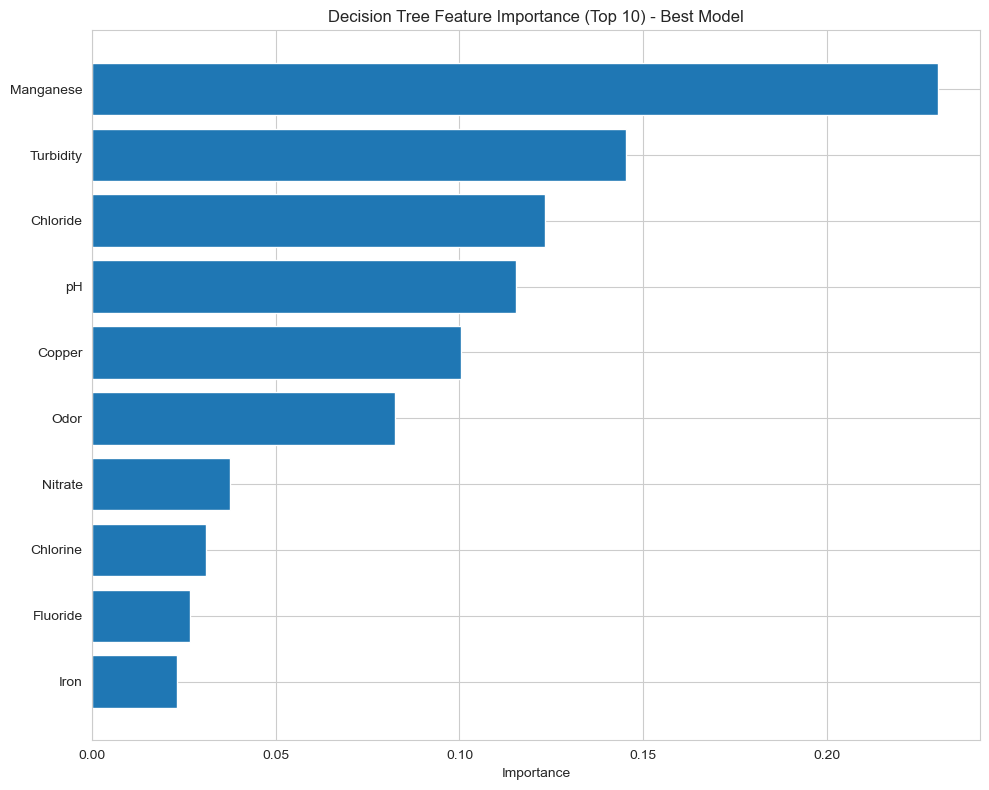

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

feature_importance_dt = pd.DataFrame({
    'Feature': X_train_dt.columns,
    'Importance': best_dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance_dt)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_dt['Feature'][:10], feature_importance_dt['Importance'][:10])
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Decision Tree Feature Importance (Top 10) - Best Model')
plt.tight_layout()
plt.savefig('../reports/figures/dt_feature_importance.png', dpi=300)
plt.show()

The Decision Tree model shows that **Manganese** is the most important factor for water quality, followed by **Turbidity** and **Chloride**. These three features alone explain about 50% of the model's decision-making.

It is interesting that **pH** ranks high (4th) in the Decision Tree model, even though it had a weak correlation with Target in the EDA stage. This shows that pH may have a non-linear relationship with water safety, which the Decision Tree can capture but a simple correlation cannot.

Heavy metals and chemicals like Manganese, Chloride, and Copper appear as top predictors, which matches the EDA findings. This suggests that chemical pollution is a key factor in determining water safety, not just physical properties like Turbidity alone.

#### 11. Tree Visualization

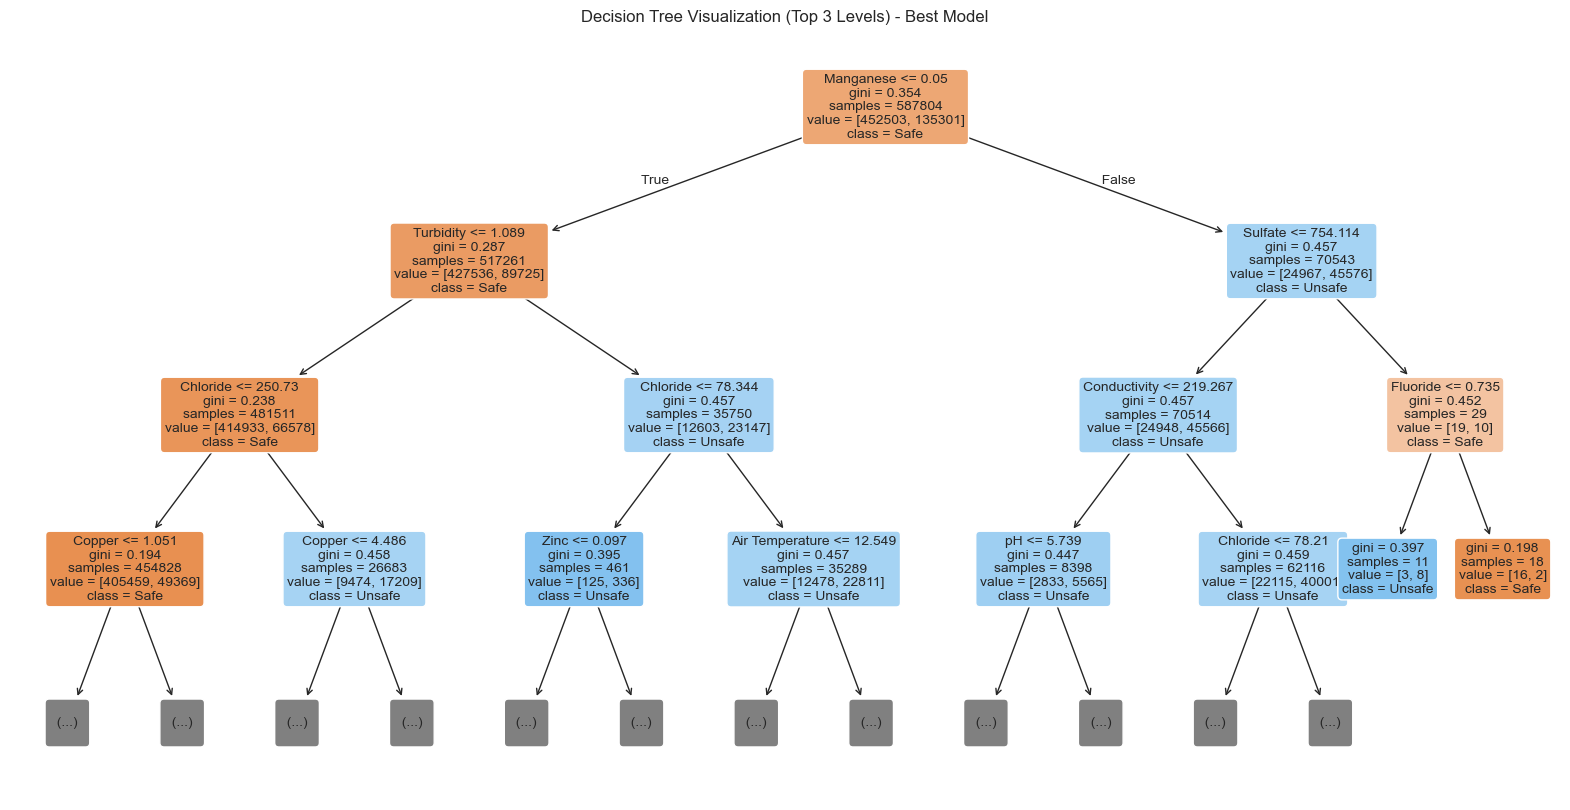

In [22]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    best_dt_model,
    max_depth=3,
    feature_names=X_train_dt.columns,
    class_names=['Safe', 'Unsafe'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree Visualization (Top 3 Levels) - Best Model')
plt.savefig('../reports/figures/dt_tree_visualization.png', dpi=300, bbox_inches='tight')
plt.show()